## Loading and Merging of Datasets

In [1]:
import pandas as pd
import numpy as np

independent_features = pd.read_csv('smartphone_battery_features.csv')
dependent_feature = pd.read_csv('smartphone_battery_targets.csv')
df = independent_features.merge(dependent_feature, on='Device_ID', how='inner')
df.head()

,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,67.2,Replace Battery


## Dropping Irrelevant Feature

In [2]:
print("Shape before dropping ID:", df.shape)
df.drop(columns=['Device_ID'], inplace=True)
print("Shape after dropping ID:", df.shape)

print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

Shape before dropping ID: (5000, 17)
Shape after dropping ID: (5000, 16)

Null Values:
 device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
current_battery_health_percent      0
recommended_action                  0
dtype: int64

Duplicated Rows: 0


## Outlier Analysis

In [3]:
numerical_columns = df.select_dtypes(include='number').columns[:-1]

n_rows = 4
n_cols = 4

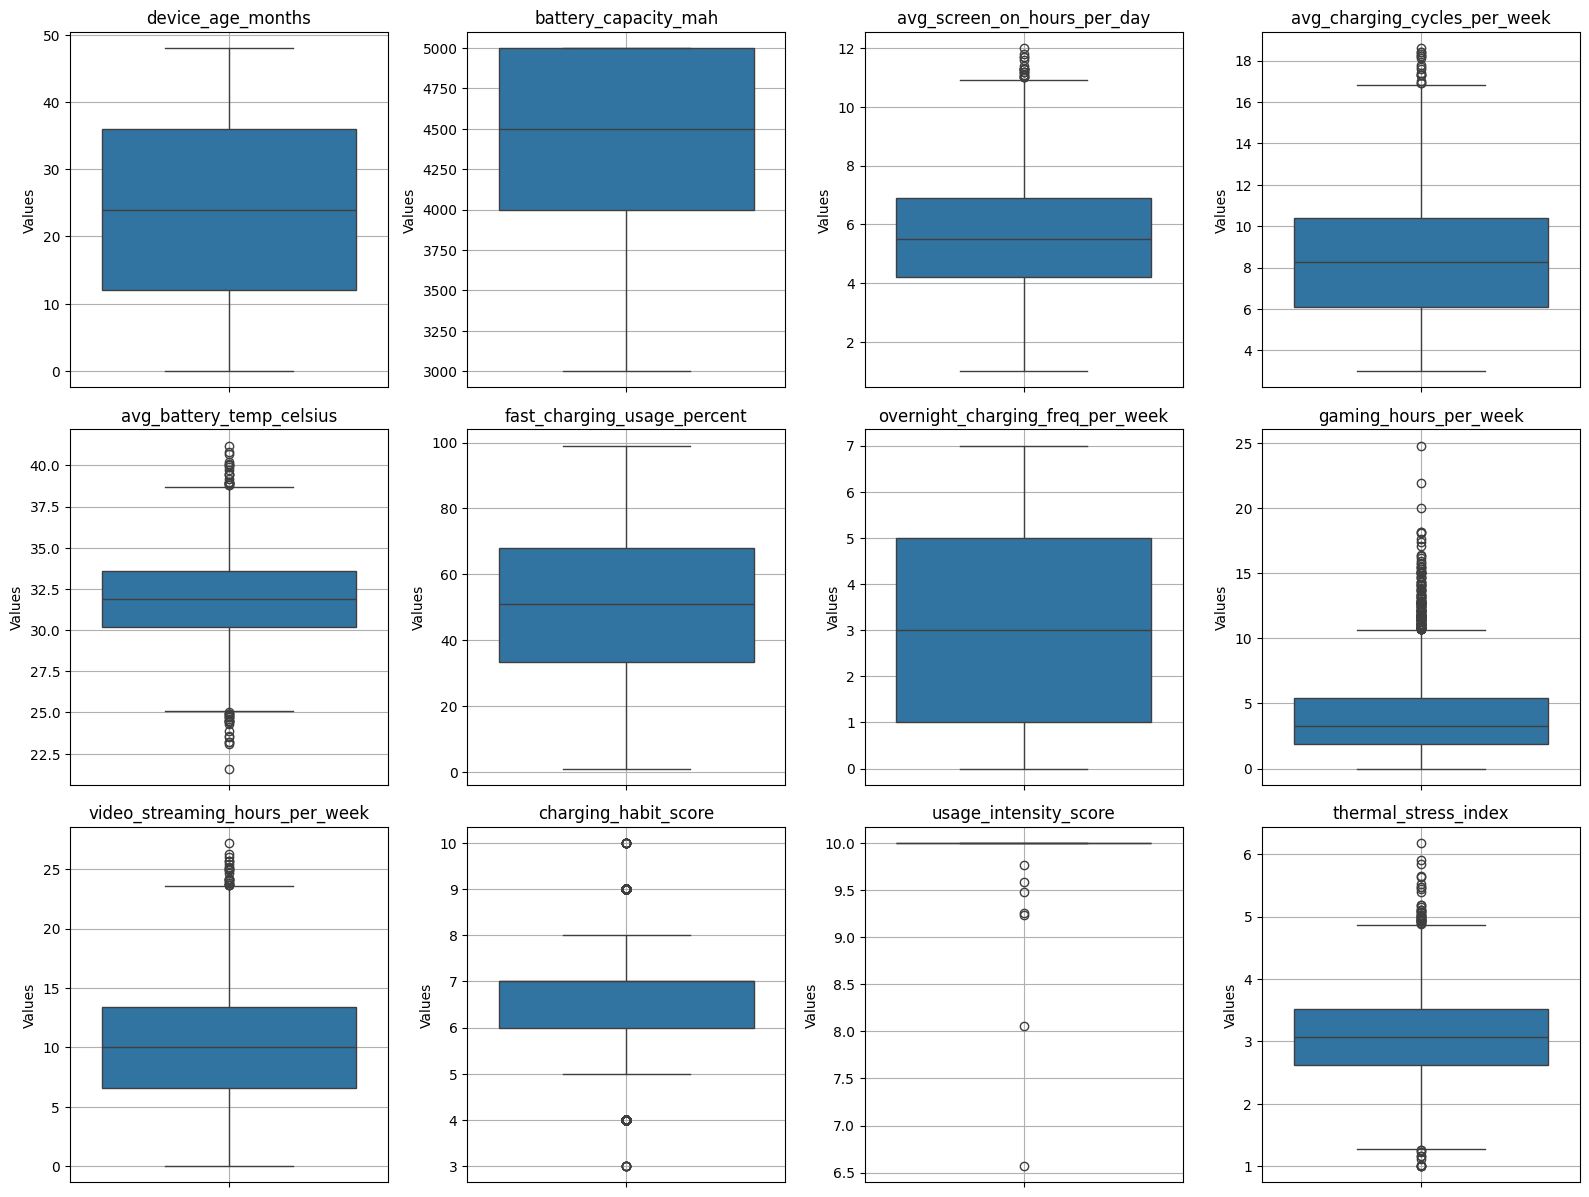

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for index, column in enumerate(numerical_columns):
    sns.boxplot(data=df[column], ax=axes[index])
    axes[index].set_title(column)
    axes[index].set_ylabel('Values')
    axes[index].grid(True)
    
for i in range(len(numerical_columns), len(axes)):
    plt.delaxes(axes[i])
    
plt.tight_layout()
plt.show()

## Train-Test Data Spliting

In [5]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :14]
Y = df.iloc[:, 14]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

X_train.head()

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
1840,13,5000,5.7,8.4,34.6,62.0,1,4.2,7.3,Medium,Good,8,10.0,3.74
2115,42,3000,10.7,14.2,36.5,97.1,1,7.4,12.8,High,Good,6,10.0,4.41
4437,22,4000,6.4,8.8,33.6,61.1,5,4.9,8.6,Medium,Moderate,5,10.0,3.53
1146,32,3000,3.5,3.6,32.4,22.8,7,5.6,8.0,High,Good,6,10.0,3.31
2486,15,4000,7.1,11.5,38.2,68.6,5,12.6,11.0,High,Good,6,10.0,5.18


## Label Encoding Categorical Features

In [6]:
import joblib
from sklearn.preprocessing import LabelEncoder

label_encoder = {}

for column in X_train.select_dtypes(include='object'):
    le = LabelEncoder()
    X_train[column] = le.fit_transform(X_train[column])
    X_test[column] = le.transform(X_test[column])
    label_encoder[column] = le
    
joblib.dump(label_encoder, 'Label-Encoder.bin')
print("✅ Label Encoders saved as 'Label-Encoder.bin'")

✅ Label Encoders saved as 'Label-Encoder.bin'


## Features Scaling

In [7]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_test = rs.transform(X_test)

joblib.dump(rs, 'Robust-Scaler.bin')
print("✅ Robust Scaler saved as 'Robust-Scaler.bin'")
print(f'Training data input shape : {X_train.shape}')
print(f'Testing data input shape  : {X_test.shape}')

✅ Robust Scaler saved as 'Robust-Scaler.bin'
Training data input shape : (3500, 14)
Testing data input shape  : (1500, 14)


## Building, Training, and Testing of ML Models

In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor, XGBRFRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "8"

ml_models_dict = {
    'Linear-Regressor': LinearRegression(),
    'RandomForest-Regressor': RandomForestRegressor(random_state=42),
    'AdaBoost-Regressor': AdaBoostRegressor(random_state=42),
    'GradientBoosting-Regressor': GradientBoostingRegressor(random_state=42),
    'XGBoost-Regressor': XGBRegressor(random_state=42),
    'XGBoostRF-Booster': XGBRFRegressor(random_state=42),
    'LightGBM-Regressor': LGBMRegressor(random_state=42),
    'CatBoost-Regressor': CatBoostRegressor(verbose=0, random_state=42)
}

for model_name, model in ml_models_dict.items():
    print(f'\n-------------------- {model_name} --------------------')
    model.fit(X_train, Y_train)
    Y_pred_train = model.predict(X_train)
    Y_pred_test = model.predict(X_test)
    
    print(f"Train R²-Score : {r2_score(Y_train, Y_pred_train):.4f}")
    print(f"Test R²-Score  : {r2_score(Y_test, Y_pred_test):.4f}")


-------------------- Linear-Regressor --------------------
Train R²-Score : 0.9312
Test R²-Score  : 0.9301

-------------------- RandomForest-Regressor --------------------
Train R²-Score : 0.9941
Test R²-Score  : 0.9579

-------------------- AdaBoost-Regressor --------------------
Train R²-Score : 0.9344
Test R²-Score  : 0.9276

-------------------- GradientBoosting-Regressor --------------------
Train R²-Score : 0.9728
Test R²-Score  : 0.9635

-------------------- XGBoost-Regressor --------------------
Train R²-Score : 0.9967
Test R²-Score  : 0.9572

-------------------- XGBoostRF-Booster --------------------
Train R²-Score : 0.9564
Test R²-Score  : 0.9424

-------------------- LightGBM-Regressor --------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1310
[LightGBM]

d:\Predictor_Applications v1.2\Smartphone_Battery_Health_Predictor v1.0\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\Predictor_Applications v1.2\Smartphone_Battery_Health_Predictor v1.0\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train R²-Score : 0.9873
Test R²-Score  : 0.9645


## Saving the ML Models

In [9]:
import pickle

for model_name, model in ml_models_dict.items():
    with open(f'{model_name}_Model.pkl', 'wb') as file:
        pickle.dump(model, file)
        
    with open(f'{model_name}_Model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)
        
    print(f'Accuracy of the loaded {model_name} model : {loaded_model.score(X_test, Y_test):.4f}')

Accuracy of the loaded Linear-Regressor model : 0.9301
Accuracy of the loaded RandomForest-Regressor model : 0.9579
Accuracy of the loaded AdaBoost-Regressor model : 0.9276
Accuracy of the loaded GradientBoosting-Regressor model : 0.9635
Accuracy of the loaded XGBoost-Regressor model : 0.9572
Accuracy of the loaded XGBoostRF-Booster model : 0.9424
Accuracy of the loaded LightGBM-Regressor model : 0.9613
Accuracy of the loaded CatBoost-Regressor model : 0.9645


d:\Predictor_Applications v1.2\Smartphone_Battery_Health_Predictor v1.0\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Building the DL Models

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Reshape, Conv1D, MaxPooling1D, BatchNormalization, LSTM, GRU, Bidirectional, Dropout, Dense

def DNN_Model(input_shape):
    # ----------------- Input -----------------
    input = Input(shape=input_shape)
    
    # ---------------- Block 1 ----------------
    x = Dense(256, activation='relu')(input)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 2 ----------------
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 3 ----------------
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # ----------------- Output -----------------
    output = Dense(1)(x)
    
    # ---------------- Model Compilation ----------------
    model = Model(inputs=input, outputs=output, name='DNN')
    model.compile(optimizer='adam', loss='mae', metrics=['r2_score'])
    return model


def Advanced_Hybrid_DL_Models(input_shape, rnn_type, bidirectional=False, name='Hybrid'):
    # ----------------- Input -----------------
    input = Input(shape=input_shape)
    x = Reshape((input_shape[0], 1))(input)
    
    # ---------------- Block 1 ----------------
    x = Conv1D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    
    rnn_units_1 = 128 if bidirectional else 256
    rnn_layer_1 = LSTM(rnn_units_1, return_sequences=True) if rnn_type == 'LSTM' else GRU(rnn_units_1, return_sequences=True)
    x = Bidirectional(rnn_layer_1)(x) if bidirectional else rnn_layer_1(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 2 ----------------
    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    
    rnn_units_2 = 64 if bidirectional else 128
    rnn_layer_2 = LSTM(rnn_units_2, return_sequences=True) if rnn_type == 'LSTM' else GRU(rnn_units_2, return_sequences=True)
    x = Bidirectional(rnn_layer_2)(x) if bidirectional else rnn_layer_2(x)
    x = Dropout(0.2)(x)
    
    # ---------------- Block 3 ----------------
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)
    
    rnn_units_3 = 32 if bidirectional else 64
    rnn_layer_3 = LSTM(rnn_units_3, return_sequences=False) if rnn_type == 'LSTM' else GRU(rnn_units_3, return_sequences=False)
    x = Bidirectional(rnn_layer_3)(x) if bidirectional else rnn_layer_3(x)
    
    # ----------------- Output -----------------
    output = Dense(1)(x)
    
    # ---------------- Model Compilation ----------------
    model = Model(inputs=input, outputs=output, name=name)
    model.compile(optimizer='adam', loss='mae', metrics=['r2_score'])
    return model


input_shape = (X_train.shape[1],)

hybrid_dl_models = {
    'DNN': DNN_Model(input_shape),
    'CNN-LSTM': Advanced_Hybrid_DL_Models(input_shape, rnn_type='LSTM', bidirectional=False, name='CNN-LSTM'),
    'CNN-BiLSTM': Advanced_Hybrid_DL_Models(input_shape, rnn_type='LSTM', bidirectional=True, name='CNN-BiLSTM'),
    'CNN-GRU': Advanced_Hybrid_DL_Models(input_shape, rnn_type='GRU', bidirectional=False, name='CNN-GRU'),
    'CNN-BiGRU': Advanced_Hybrid_DL_Models(input_shape, rnn_type='GRU', bidirectional=True, name='CNN-BiGRU')
}

for name, model in hybrid_dl_models.items():
    print(f"\n{name} Model Summary:")
    model.summary()


DNN Model Summary:


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,849 (183.00 KB)

 Trainable params: 45,953 (179.50 KB)

...

Model: "CNN-BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 14, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 14, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 7, 256)         │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 7, 128)         │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 3, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 3, 128)         │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 3, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,713 (1.97 MB)

 Trainable params: 514,817 (1.96 MB)

 Non-trainable params: 896 (3.50 KB)

## Training of DL Models

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

hybrid_dl_models_history = {}

print('✅ Starting Deep Learning Models Training....\n')

for name, model in hybrid_dl_models.items():
    print(f"{'='*50}\nTraining {name} Model\n{'='*50}")
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    checkpoint = ModelCheckpoint(f'{name}_Model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
    
    history = model.fit(
        X_train, Y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_test, Y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    
    hybrid_dl_models_history[name] = history
    print(f"✅ {name} Training Completed. Best model saved as '{name}_Model.keras'\n")

✅ Starting Deep Learning Models Training....

Training DNN Model
Epoch 1/100
107/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 62.4300 - r2_score: -12.2452
Epoch 1: val_loss improved from None to 60.92190, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 61.8360 - r2_score: -12.1910 - val_loss: 60.9219 - val_r2_score: -11.8716
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 60.2871 - r2_score: -11.4149
Epoch 2: val_loss improved from 60.92190 to 56.90626, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 58.9972 - r2_score: -11.1736 - val_loss: 56.9063 - val_r2_score: -10.3833
Epoch 3/100
101/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 54.1258 - r2_score: -9.4491
Epoch 3: val_loss improved from 56.90626 to 48.29133, saving model to DNN_Model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 52.6791 - r2_score: -8.8621 - val_loss: 48.2913 - val_r2_score: -7.4098
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4

## Testing of DL Models

In [12]:
results = []

for name, model in hybrid_dl_models.items():
    Y_pred_train = model.predict(X_train, verbose=1)
    Y_pred_test = model.predict(X_test, verbose=1)
    
    train_r2 = r2_score(Y_train, Y_pred_train)
    test_r2 = r2_score(Y_test, Y_pred_test)
    
    results.append({"DL Model": name, "Train R²-Score": train_r2, "Test R²-Score": test_r2})

results_df = pd.DataFrame(results)
display(results_df)

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


,DL Model,Train R²-Score,Test R²-Score
0,DNN,0.969499,0.962807
1,CNN-LSTM,0.969599,0.954127
2,CNN-BiLSTM,0.969496,0.949730
3,CNN-GRU,0.970521,0.955910
4,CNN-BiGRU,0.969250,0.950506


## Plotting the Required Graphs

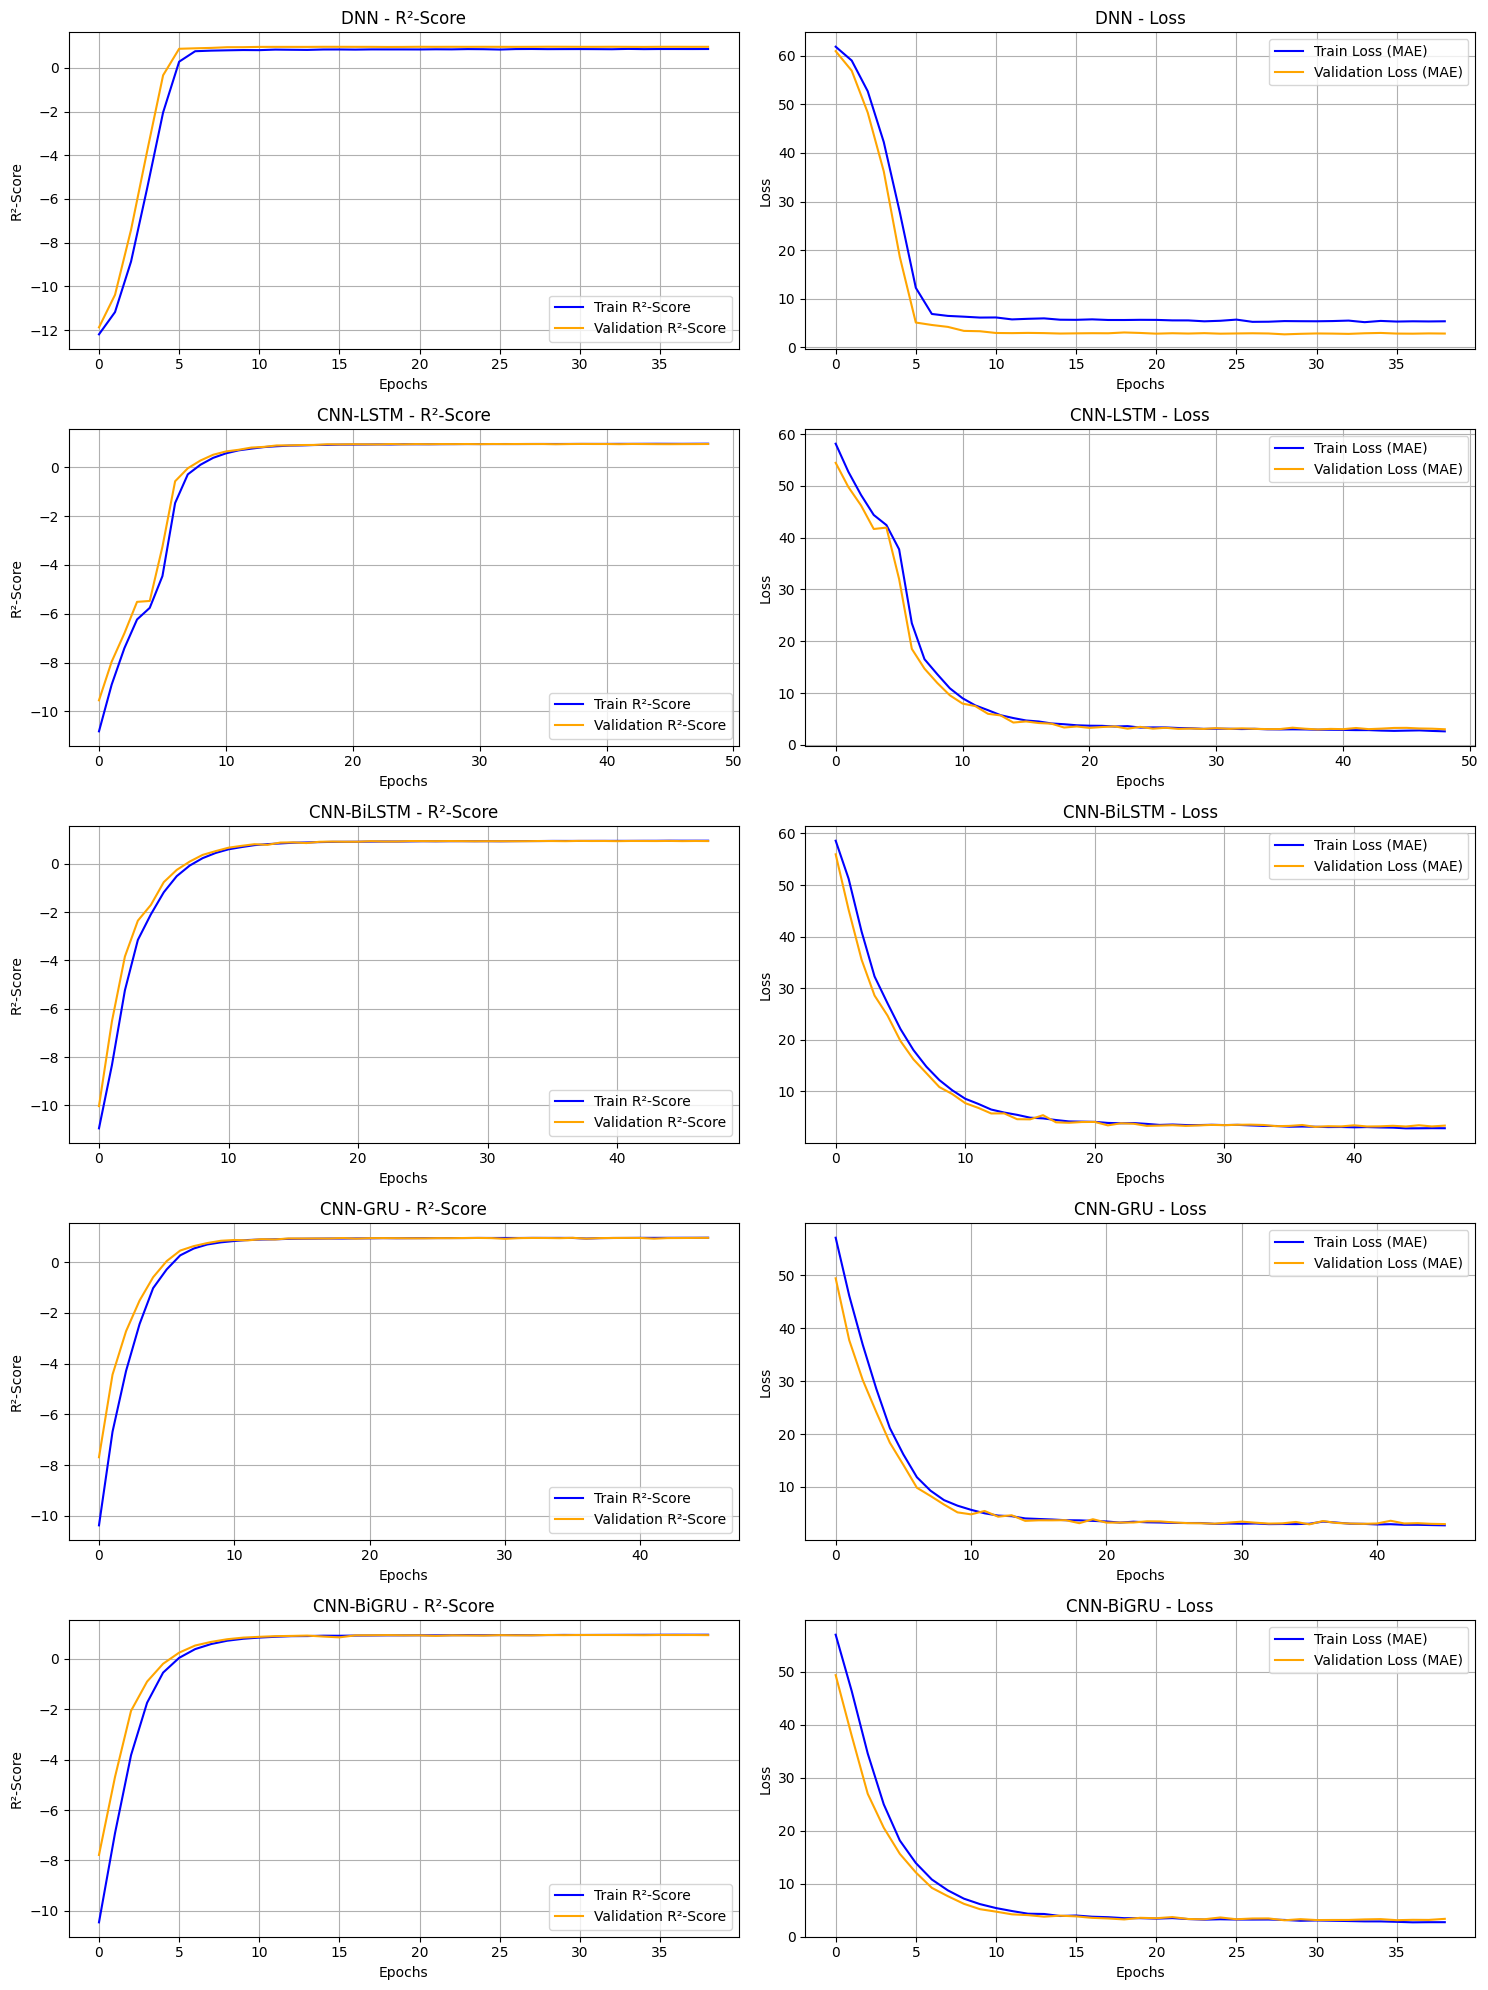

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

num_models = len(hybrid_dl_models)
fig, axes = plt.subplots(num_models, 2, figsize=(15, 4 * num_models))

for i, (name, history) in enumerate(hybrid_dl_models_history.items()):
    # 1. Plot R²-Score
    axes[i, 0].plot(history.history['r2_score'], label='Train R²-Score', color='blue')
    axes[i, 0].plot(history.history['val_r2_score'], label='Validation R²-Score', color='orange')
    axes[i, 0].set_title(f'{name} - R²-Score')
    axes[i, 0].set_xlabel('Epochs')
    axes[i, 0].set_ylabel('R²-Score')
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # 2. Plot Loss
    axes[i, 1].plot(history.history['loss'], label='Train Loss (MAE)', color='blue')
    axes[i, 1].plot(history.history['val_loss'], label='Validation Loss (MAE)', color='orange')
    axes[i, 1].set_title(f'{name} - Loss')
    axes[i, 1].set_xlabel('Epochs')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

## DL Models Output Comparison

In [14]:
from tensorflow.keras.models import load_model

# Prepare the full dataset for prediction
X_full = df.iloc[:, :14].copy()

encoders = joblib.load('Label-Encoder.bin')
for column in X_full.select_dtypes(include='object'):
    X_full[column] = encoders[column].transform(X_full[column])

scaler = joblib.load('Robust-Scaler.bin')
X_full_scaled = scaler.transform(X_full)

print("Generating predictions for the full dataset using all Deep Learning models...\n")

# Predict with each saved model and append as a new column
for name in hybrid_dl_models.keys():
    saved_model = load_model(f'{name}_Model.keras')
    predictions = saved_model.predict(X_full_scaled, verbose=0)
    df[f'{name}_Predicted_Output'] = predictions

# Save final dataset
output_file = 'smartphone_battery_health_with_all_predictions.csv'
df.to_csv(output_file, index=False)
print(f"✅ Predictions saved successfully to: {output_file}\n")

# View the original targets alongside the new predictions
display_columns = ['current_battery_health_percent'] + [f'{name}_Predicted_Output' for name in hybrid_dl_models.keys()]
df[display_columns].head(10)

Generating predictions for the full dataset using all Deep Learning models...

✅ Predictions saved successfully to: smartphone_battery_health_with_all_predictions.csv



,current_battery_health_percent,DNN_Predicted_Output,CNN-LSTM_Predicted_Output,CNN-BiLSTM_Predicted_Output,CNN-GRU_Predicted_Output,CNN-BiGRU_Predicted_Output
0,32.8,28.914572,30.534241,34.969620,32.210560,28.763292
1,50.3,50.484852,47.628620,51.892979,52.115314,49.706165
2,66.1,67.788116,68.729691,68.315331,68.768929,73.465340
3,46.8,44.357189,42.229610,42.612141,43.743961,44.274544
4,67.2,69.178680,66.013031,64.752739,65.870163,68.023911
5,69.5,69.106873,68.232437,67.158409,67.332146,69.474564
6,35.5,38.411419,35.260483,38.280205,36.613605,35.950127
7,66.3,70.080025,67.733093,67.106659,68.662285,68.335358
8,56.7,56.001759,53.641087,55.936024,55.245800,55.122299
9,85.2,79.317528,81.491707,79.164093,80.262039,79.526047
